# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd # importar librerías
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')

users = pd.read_csv("/datasets/users_latam.csv") #completa el código

usage = pd.read_csv("/datasets/usage.csv") #completa el código

In [3]:
plans.head(5)
# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
None


In [8]:
# inspección de users con .info()
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None


In [9]:
# inspección de usage con .info()
print(usage.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:

# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

**Respuesta**: 
- City: presenta 469 registros con valores faltantes, lo que representa el 11.73% del total de observaciones. Se recomienda evaluar estrategias de imputación, utilizando información disponible en otras variables o asignando una categoría como "Desconocida", según los objetivos del análisis.
- Churn_date: registra 3,534 valores nulos, equivalentes al 88.35% del conjunto de datos. Antes de eliminar o imputar estos registros, es importante validar el significado de los valores faltantes.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

In [12]:
# explorar columnas numéricas de users
columnas_numericas = ["user_id", "age"]
sentinels = [-999, 999, 0, -1]

for col in columnas_numericas:
    print(col, users[col].isin(sentinels).sum())

user_id 0
age 55


- La columna `user_id` no contiene sentinels por lo que no se identifican anomalías.
- La columna `age` contiene 55 snetinels lo que indica la presencia de registros con edades invalidas o con datos faltantes.

In [13]:
# explorar columnas numéricas de usage
columnas_numericas = ["user_id", "id"]
sentinels = [-999, 999, 0, -1]

for col in columnas_numericas:
    print(col, usage[col].isin(sentinels).sum())


user_id 0
id 1


- Las columna `id` contiene 1 sentinel y `user_id` no contiene sentinels

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
sentinels = [-999, 999, 0, -1]

for col in columnas_user:
    print(col, users[col].isin(sentinels).sum())


city 0
plan 0


- La columna `city` no se observan sentinels
- La columna `plan` no se observan sentinels

In [15]:
# explorar columna categórica de usage
columnas_usage = ['type'] # completa el código
sentinels = [-999, 999, 0, -1]

for col in columnas_usage:
    print(col, usage[col].isin(sentinels).sum())

type 0


- La columna `type` no contiene sentinels


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Respuesta**
Se encontaron sentinels en "age" y en "id" se recomienda reemplazarlos por valores nulos (NaN) para facilitar su tratamiento y evaluar el impacto que estos registros puedan tener en el analisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])  # completa el código
print(users["reg_date"])

0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código
print(usage["date"])

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]


In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se identificaron registros correspondientes a los años 2022, 2023 y 2024, con 1,314, 1,316 y 1,330 registros respectivamente. Asimismo, se observaron 40 registros correspondientes al año 2026.

La presencia de registros con fechas en 2026 podría indicar posibles valores inválidos o inconsistencias en la captura de datos, especialmente si el período de análisis esperado no contempla años futuros.

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`,se observó que la totalidad de los registros corresponde al año 2024, con un total de 39,950 observaciones. No se identificaron registros de otros años, lo que sugiere que los datos se encuentran concentrados en un único período temporal y no presentan inconsistencias relacionadas con fechas fuera del rango esperado.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [21]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace("?", pd.NA)

# Verificar cambios
print(users['city'].describe())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object


In [22]:
# Marcar fechas futuras como NA para reg_date

users.loc[users["reg_date"] > pd.Timestamp.today(), "reg_date"] = pd.NaT

# Verificar cambios
print(users['reg_date'].describe())

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- 
Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.


In [23]:
# Verificación MAR en usage (Missing At Random) para duration

print("Nulos en duration por tipo:")
print(usage["duration"].isna().groupby(usage["type"]).sum())

Nulos en duration por tipo:
type
call        0
text    22076
Name: duration, dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print("Nulos en duration por length:")
print(usage["length"].isna().groupby(usage["type"]).sum())

Nulos en duration por length:
type
call    17896
text        0
Name: length, dtype: int64


Al analizar los valores faltantes en las columnas "duration" y 'length' según la variable type, se identificó que los nulos están relacionados con el tipo de registro.

La columna duration no presenta valores nulos para los registros de tipo "call", pero contiene 22,076 valores faltantes en los registros de tipo "text". Por otro lado, la columna "length" presenta 17,896 valores nulos para los registros de tipo call, mientras que los registros de tipo text no presentan valores faltantes.

Debido a que la ausencia de datos está asociada con una variable observable dentro del dataset (type), los valores faltantes pueden considerarse MAR (Missing At Random). No se recomienda imputar estos valores, ya que la falta de información está relacionada con la naturaleza del registro. Asignar valores artificiales podría distorsionar el comportamiento real de los datos y afectar los análisis posteriores.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso


🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.


In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [42]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 *
*Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile["plan"].value_counts(normalize=True) * 100

print(plan_distribution.round(2))

Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 
**Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


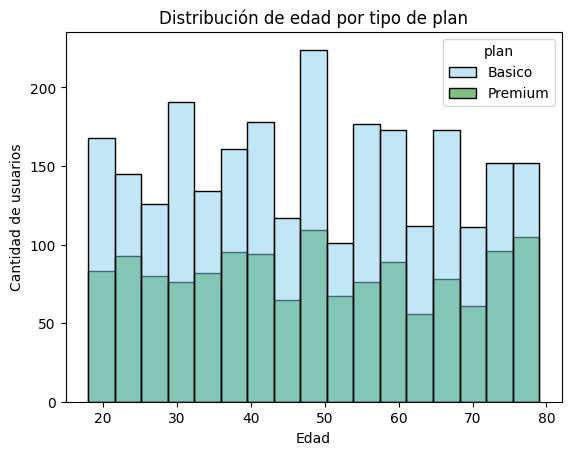

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=users,
    x="age",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de edad por tipo de plan")

plt.show()

💡Insights: 
- Al analizar la distribución de edad según el tipo de plan, se observa que la edad por sí sola no presenta diferencias significativas entre los usuarios del plan Básico y Premium. Ambos grupos muestran rangos y concentraciones de edad similares, lo que sugiere que la elección del tipo de plan probablemente está influenciada por otros factores, como los patrones de consumo, necesidades de uso o comportamiento del cliente, más que por la edad del usuario.

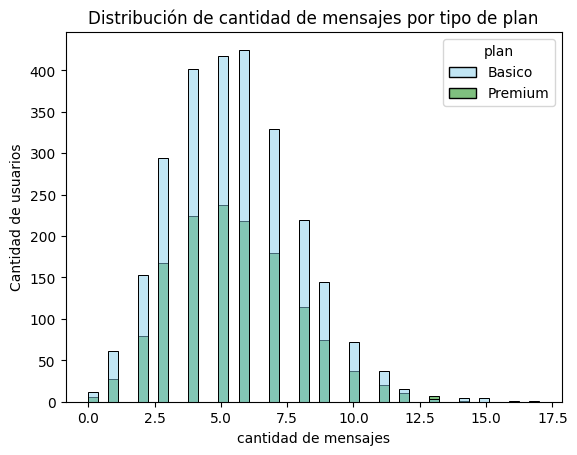

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.xlabel("cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de cantidad de mensajes por tipo de plan")

plt.show()

💡Insights: 
- La distribución de la cantidad de mensajes por tipo de plan presenta un sesgo hacia la derecha, indicando que la mayoría de los usuarios tiene un consumo moderado de mensajes, mientras que un grupo reducido presenta cantidades significativamente más altas. Se observa una mayor concentración de usuarios entre aproximadamente 3 y 7 mensajes, con pocos usuarios que alcanzan volúmenes elevados de mensajería. Este comportamiento sugiere que la mayoría mantiene un patrón de uso bajo o moderado, mientras que algunos usuarios presentan un consumo intensivo del servicio.

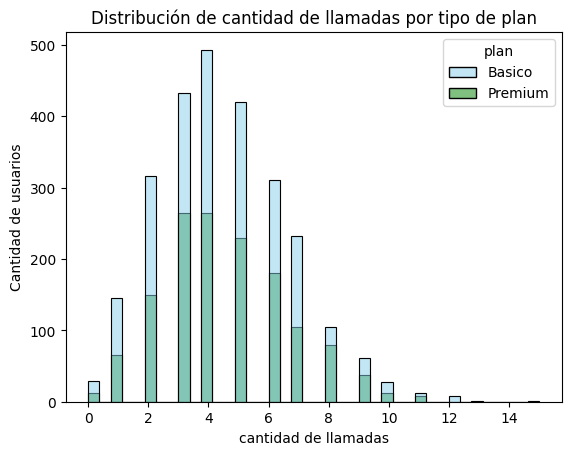

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.xlabel("cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de cantidad de llamadas por tipo de plan")

plt.show()

💡Insights: 
- La distribución de la cantidad de llamadas por tipo de plan presenta un sesgo hacia la derecha, indicando que la mayoría de los usuarios realiza una cantidad moderada de llamadas, mientras que un grupo reducido presenta valores más elevados. Se observa que la mayor concentración de usuarios se encuentra entre 2 y 6 llamadas, con una frecuencia máxima cercana a 4 llamadas. En general, los usuarios de los planes Básico y Premium muestran patrones de comportamiento similares, por lo que la cantidad de llamadas no parece ser un factor diferenciador significativo entre ambos planes.

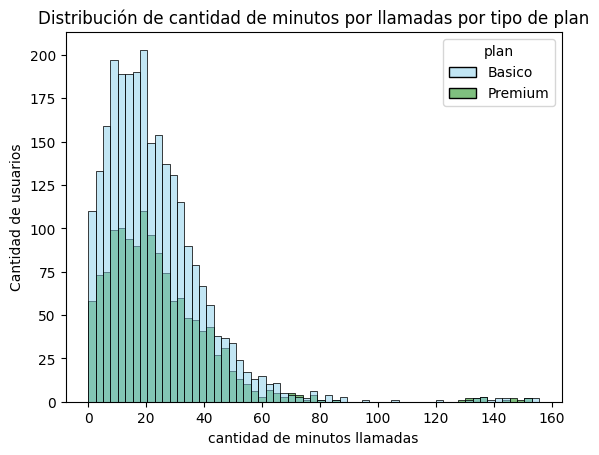

In [33]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.xlabel("cantidad de minutos llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de cantidad de minutos por llamadas por tipo de plan")

plt.show()



💡Insights: 
- La distribución de los minutos de llamadas por tipo de plan presenta un sesgo hacia la derecha, indicando que la mayoría de los usuarios mantiene un consumo moderado de minutos, mientras que un grupo reducido presenta valores significativamente más altos.

Se observa que la mayor concentración de usuarios se encuentra aproximadamente entre 0 y 40 minutos de llamadas, con una mayor frecuencia alrededor de los 15–20 minutos.

### 5.2 Identificación de Outliers

🎯 

**Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.



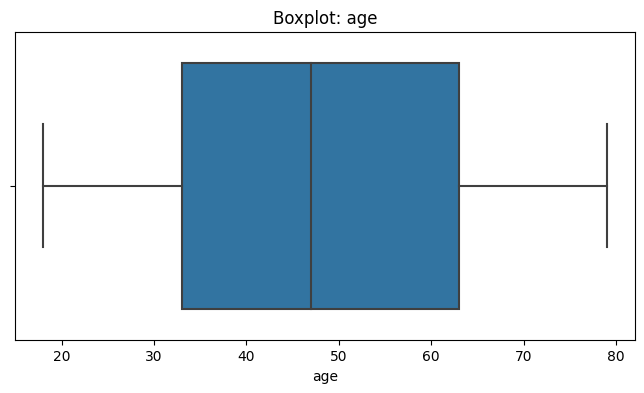

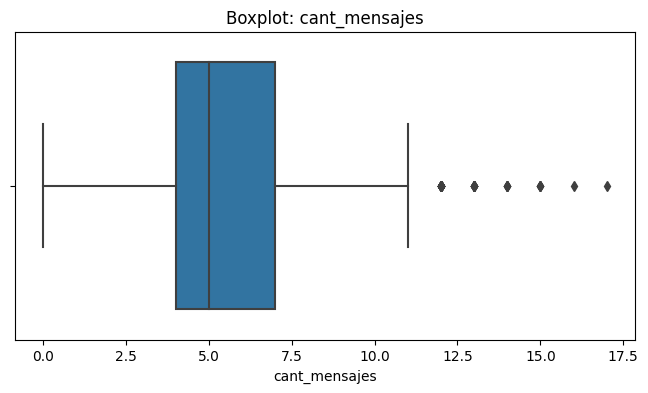

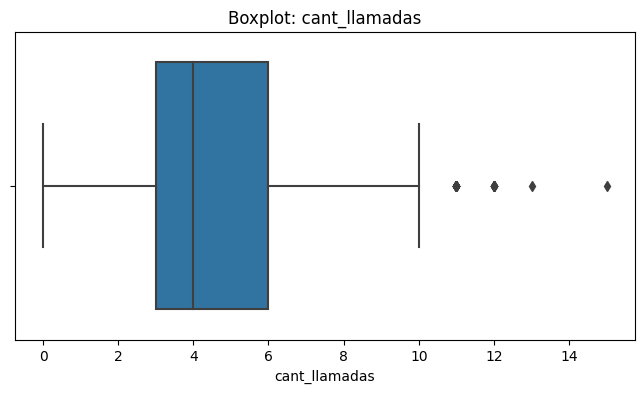

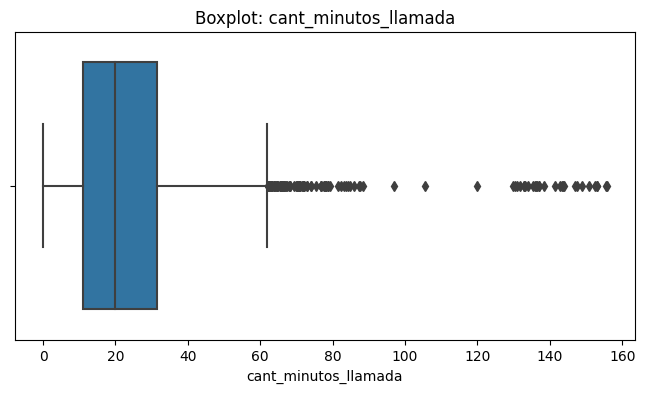

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        data=user_profile,
        x=col
    )
    
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    
    plt.show()

💡Insights: 
- Age: El boxplot de edad no presenta una cantidad significativa de valores extremos. Los usuarios se encuentran dentro de un rango esperado, por lo que no se requiere limpieza. 
- cant_mensajes: Se identifican valores extremos hacia la derecha, indicando usuarios con un volumen de mensajes considerablemente superior al promedio. Estos valores pueden representar usuarios con un uso intensivo, por lo que se recomienda conservarlos para no perder información relevante del comportamiento.
- cant_llamadas: Se observan algunos outliers superiores, correspondientes a usuarios con una cantidad elevada de llamadas. Se recomienda revisar estos registros, pero no eliminarlos automáticamente ya que pueden representar patrones reales de consumo.
- cant_minutos_llamada: La variable presenta valores extremos hacia la derecha debido a usuarios con un consumo elevado de minutos. Estos casos deben revisarse antes de aplicar cualquier limpieza, ya que pueden representar clientes con alto nivel de uso.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]
    
    print(f"\nVariable: {col}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")


Variable: age
Límite inferior: -12.00
Límite superior: 108.00
Cantidad de outliers: 0

Variable: cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50
Cantidad de outliers: 46

Variable: cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50
Cantidad de outliers: 30

Variable: cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86
Cantidad de outliers: 109


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:

cant_mensajes: mantener o no outliers, porqué? **Respuesta**: Mantener los outliers ya que los valores altos de cantidad de mensajes probablemente representan clientes conmayor nivel de actividad y no necesariamente son errores.

cant_llamadas: mantener o no outliers, porqué? **Respuesta**: Mantener los outliers pero revisarlos ya que los valores extremos puede representar clientes con uso intensivo del servicio.

cant_minutos_llamada: mantener o no outliers, porqué? **Respuesta** Mantenerlos incialmente ya que aunque hay valore extremos se puede deber que hay clientes que realizan llamadas largas. Antes de eliminar se recomienda validar si son registros reales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 
**Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [37]:

# verificar cambios
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Valores que se asignarán según cada condición
grupos = [
    'Bajo uso',
    'Uso medio'
]

# Crear nueva columna
user_profile['grupo_uso'] = np.select(
    condiciones,
    grupos,
    default='Alto uso'
)
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()


,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 
**Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos


In [38]:
# Crear columna grupo_edad
condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

# Valores asignados a cada condición
grupos_edad = [
    'Joven',
    'Adulto'
]

# Crear nueva columna grupo_edad
user_profile['grupo_edad'] = np.select(
    condiciones,
    grupos_edad,
    default='Adulto Mayor'
)

# Revisar resultado
user_profile[['age', 'grupo_edad']].head()


,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯
 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


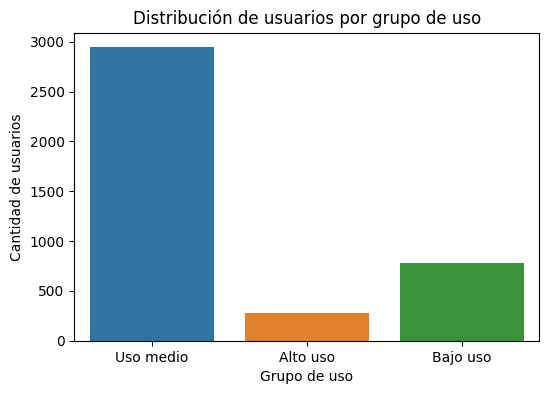

In [40]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.xticks(rotation=0)
plt.show()

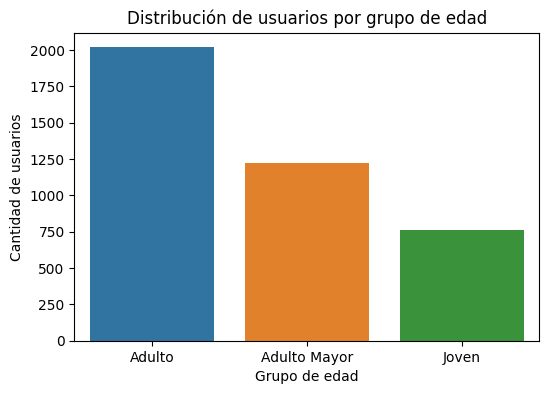

In [41]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))

sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.xticks(rotation=0)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 
**Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Durante la revisión inicial de calidad de datos se identificaron registros con valores faltantes o nulos en algunas variables del dataset. Se encontraron dos columnas con presencia significativa de datos ausentes: la primera representaba aproximadamente el 11.73% del total de observaciones, mientras que la segunda alcanzaba alrededor del 88.35% de los registros.
- Durante la revisión de la variable reg_date se identificó una inconsistencia en los registros de fecha. Al analizar los años presentes en esta columna, se encontraron valores correspondientes al año 2026, aunque la información disponible del dataset reporta registros únicamente hasta el año 2024.
Estos datos representan posibles errores de calidad, ya que contienen fechas fuera del periodo esperado de análisis.



🔍 **Segmentos por Edad**
- Durante el análisis de segmentación por edad no se evidenciaron diferencias significativas entre los grupos identificados. Los segmentos presentan una distribución similar de usuarios, lo que indica que la edad no parece ser un factor determinante para diferenciar el comportamiento general de los clientes dentro del servicio.


📊 **Segmentos por Nivel de Uso**
- Se concluye que las variables relacionadas con la cantidad de mensajes y llamadas presentan un leve sesgo hacia la derecha, lo que indica que la mayoría de los usuarios mantienen un nivel de consumo moderado. Sin embargo, existe un grupo reducido de clientes con niveles de uso significativamente más altos, representando usuarios con patrones de consumo intensivo.
- La variable cant_minutos_llamada presenta un sesgo positivo (hacia la derecha) más marcado en comparación con las demás variables de uso. Al analizar el comportamiento según el tipo de plan, se observa que el plan Básico concentra la mayor cantidad de usuarios, con un consumo promedio de minutos que se encuentra aproximadamente entre los 15 y 20 minutos de llamada.



💡 **Recomendaciones**
1. Crear planes diferenciados según el nivel de consumo
Diseñar planes ajustados al comportamiento de uso de los clientes.
Ofrecer opciones con más minutos para usuarios de alto consumo.
Crear alternativas más económicas para clientes de bajo uso.
Esto permitirá mejorar la satisfacción y percepción de valor.
2. Implementar estrategias de fidelización para clientes de alto consumo
Identificar usuarios con mayor nivel de interacción con el servicio.
Ofrecer beneficios exclusivos, descuentos o mejoras de plan.
Fortalecer la relación con clientes de mayor valor.
Esto ayudará a aumentar la retención y reducir la pérdida de usuarios.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`